In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\goyal\Downloads\global_supply_chain_risk_2026.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 5,000 rows × 14 columns


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,16-10-2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,24-04-2024,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,26-01-2024,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,08-10-2024,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,07-09-2024,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Shipment_ID,5000,5000,SC-10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,5000,731,05-04-2024,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Origin_Port,5000,8,Busan,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_Port,5000,9,Marseille,583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transport_Mode,5000,4,Air,1320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,5000,5,Electronics,1016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_km,5000.0,NaN,NaN,NaN,7704.063888,4199.687885,500.17,4036.01,7750.125,11347.4625,14995.91
Weight_MT,5000.0,NaN,NaN,NaN,246.252052,142.522591,1.03,124.33,243.5,366.955,499.75
Fuel_Price_Index,5000.0,NaN,NaN,NaN,2.854552,0.959533,1.2,2.02,2.84,3.71,4.5
Geopolitical_Risk_Score,5000.0,NaN,NaN,NaN,5.0769,2.877832,0.0,2.6,5.1,7.5,10.0


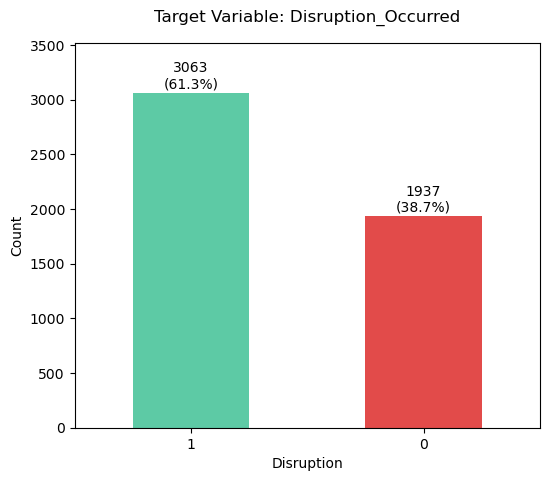

In [5]:
counts = df['Disruption_Occurred'].value_counts()

plt.figure(figsize=(6,5))

ax = counts.plot(
    kind='bar',
    color=['#5DCAA5', '#E24B4A'],
    width=0.5
)

for i, val in enumerate(counts):
    percentage = val / len(df) * 100

    ax.text(
        i,
        val + 40,
        f'{val}\n({percentage:.1f}%)',
        ha='center',
        fontsize=10
    )

plt.title("Target Variable: Disruption_Occurred", pad=15)
plt.xlabel("Disruption")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.ylim(0, counts.max() * 1.15)

plt.show()

**Insight:**
- 5,000 shipment records with 14 columns (13 features + 1 target).
- Mix of numerical (6) and categorical (5) features plus an ID and a date column.
- Target is **mildly imbalanced** (~61% disruption, ~39% no disruption) 

## 2. Data Cleaning

**Why:** Raw data often contains wrong dtypes, whitespace in strings, or logically invalid values. Cleaning ensures downstream transformations behave correctly.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)
print("Date range:", df['Date'].min().date(), '→', df['Date'].max().date())


Shipment_ID                          object
Date                         datetime64[ns]
Origin_Port                          object
Destination_Port                     object
Transport_Mode                       object
Product_Category                     object
Distance_km                         float64
Weight_MT                           float64
Fuel_Price_Index                    float64
Geopolitical_Risk_Score             float64
Weather_Condition                    object
Carrier_Reliability_Score           float64
Lead_Time_Days                      float64
Disruption_Occurred                   int64
dtype: object
Date range: 2024-01-01 → 2025-12-31


**Insight:**
- `Date` parsed correctly; spans ~2 years of shipment data.
- `Shipment_ID` dropped.

## 3. Missing Value Analysis & Handling

In [7]:
if df.isnull().sum().sum() == 0:
    print("No missing values")
else:
    print(df.isnull().sum())

No missing values


**Insight:**
- This dataset has **no missing values** still we are adding a imputer as a safety mechanism in case of unexpected missing values 

## 4. Duplicate Handling


In [8]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {n_dupes} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicate rows: 0
No duplicates found.


## 5. Univariate Analysis

 Examining each feature independently reveals its distribution shape, skewness and based on that apply the transformations

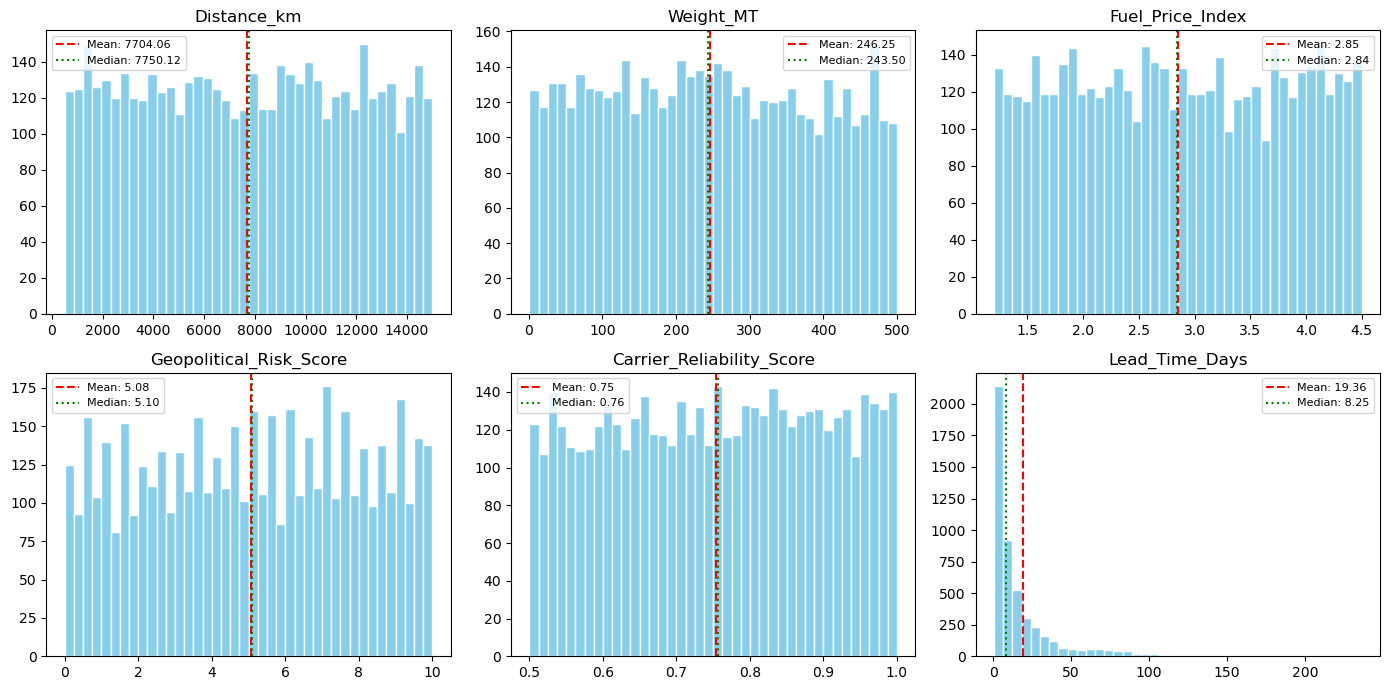

In [9]:
num_cols = [
    'Distance_km',
    'Weight_MT',
    'Fuel_Price_Index',
    'Geopolitical_Risk_Score',
    'Carrier_Reliability_Score',
    'Lead_Time_Days'
]

fig, axes = plt.subplots(2, 3, figsize=(14,7))

axes = axes.flatten()

for i, col in enumerate(num_cols):

    axes[i].hist(
        df[col],
        bins=40,
        color='skyblue',
        edgecolor='white'
    )

    mean = df[col].mean()
    median = df[col].median()

    axes[i].axvline(
        mean,
        color='red',
        linestyle='--',
        label=f'Mean: {mean:.2f}'
    )

    axes[i].axvline(
        median,
        color='green',
        linestyle=':',
        label=f'Median: {median:.2f}'
    )

    axes[i].set_title(col)

    axes[i].legend(fontsize=8)

plt.tight_layout()

plt.show()

In [10]:
skew = df[num_cols].skew().sort_values(ascending=False)
print(skew)

Lead_Time_Days               3.349223
Weight_MT                    0.045916
Fuel_Price_Index             0.007883
Distance_km                  0.003954
Carrier_Reliability_Score   -0.034601
Geopolitical_Risk_Score     -0.044614
dtype: float64


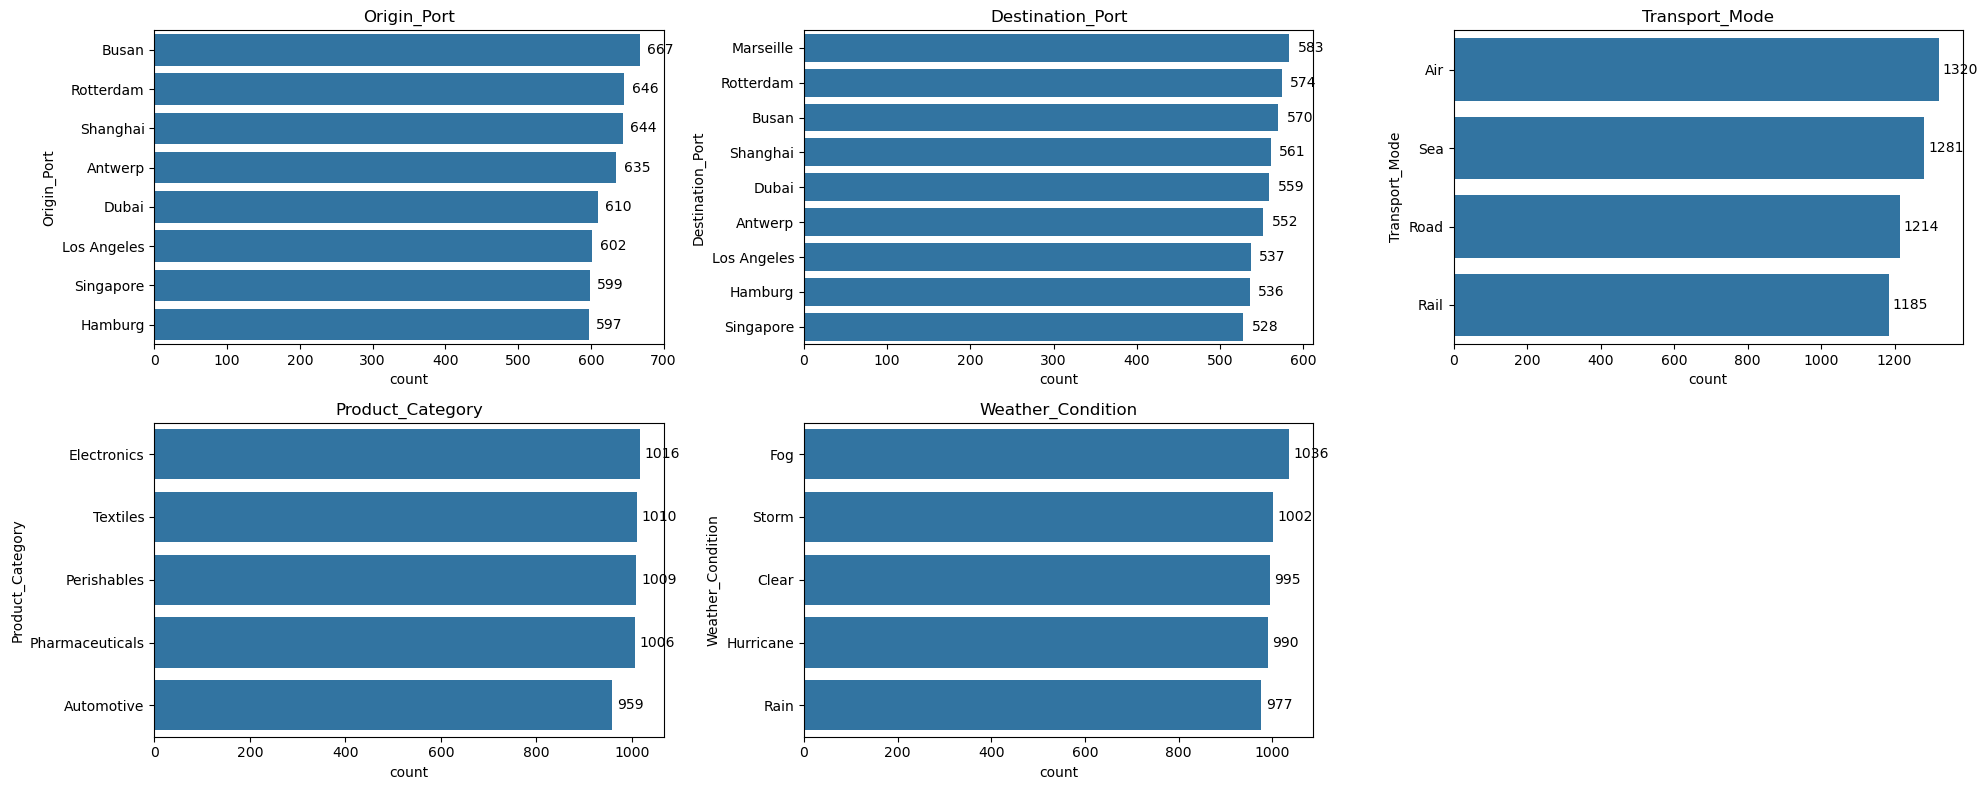

In [11]:
cat_cols = [
    'Origin_Port',
    'Destination_Port',
    'Transport_Mode',
    'Product_Category',
    'Weather_Condition'
]

fig, axes = plt.subplots(2, 3, figsize=(20,8))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(col)

    for p in axes[i].patches:

        axes[i].annotate(
            int(p.get_width()),
            (p.get_width() + 10,
             p.get_y() + p.get_height()/2),
            va='center'
        )

axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

**Insights:**
- `Lead_Time_Days` is **strongly right-skewed** (most shipments are fast; a few take very long)
- `Distance_km` and `Weight_MT` are roughly **uniform**
- `Geopolitical_Risk_Score` and `Carrier_Reliability_Score` are fairly uniform across their ranges.
- `Air` is the most common transport mode; `Busan` and `Marseille` dominate origin/destination.
- `Fog` is the most frequent weather condition (~20.7%).

## 6. Bivariate Analysis

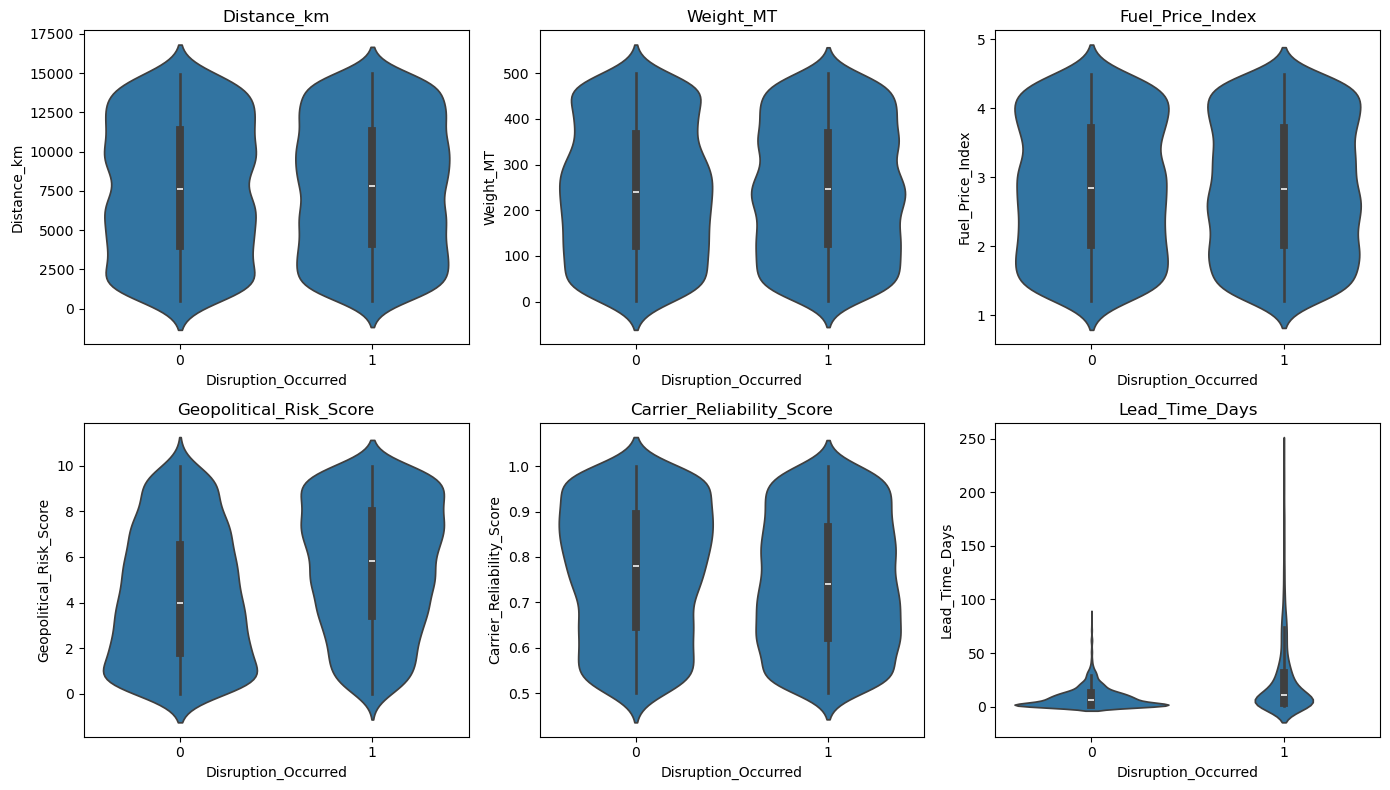

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.violinplot(
        data=df,
        x='Disruption_Occurred',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()


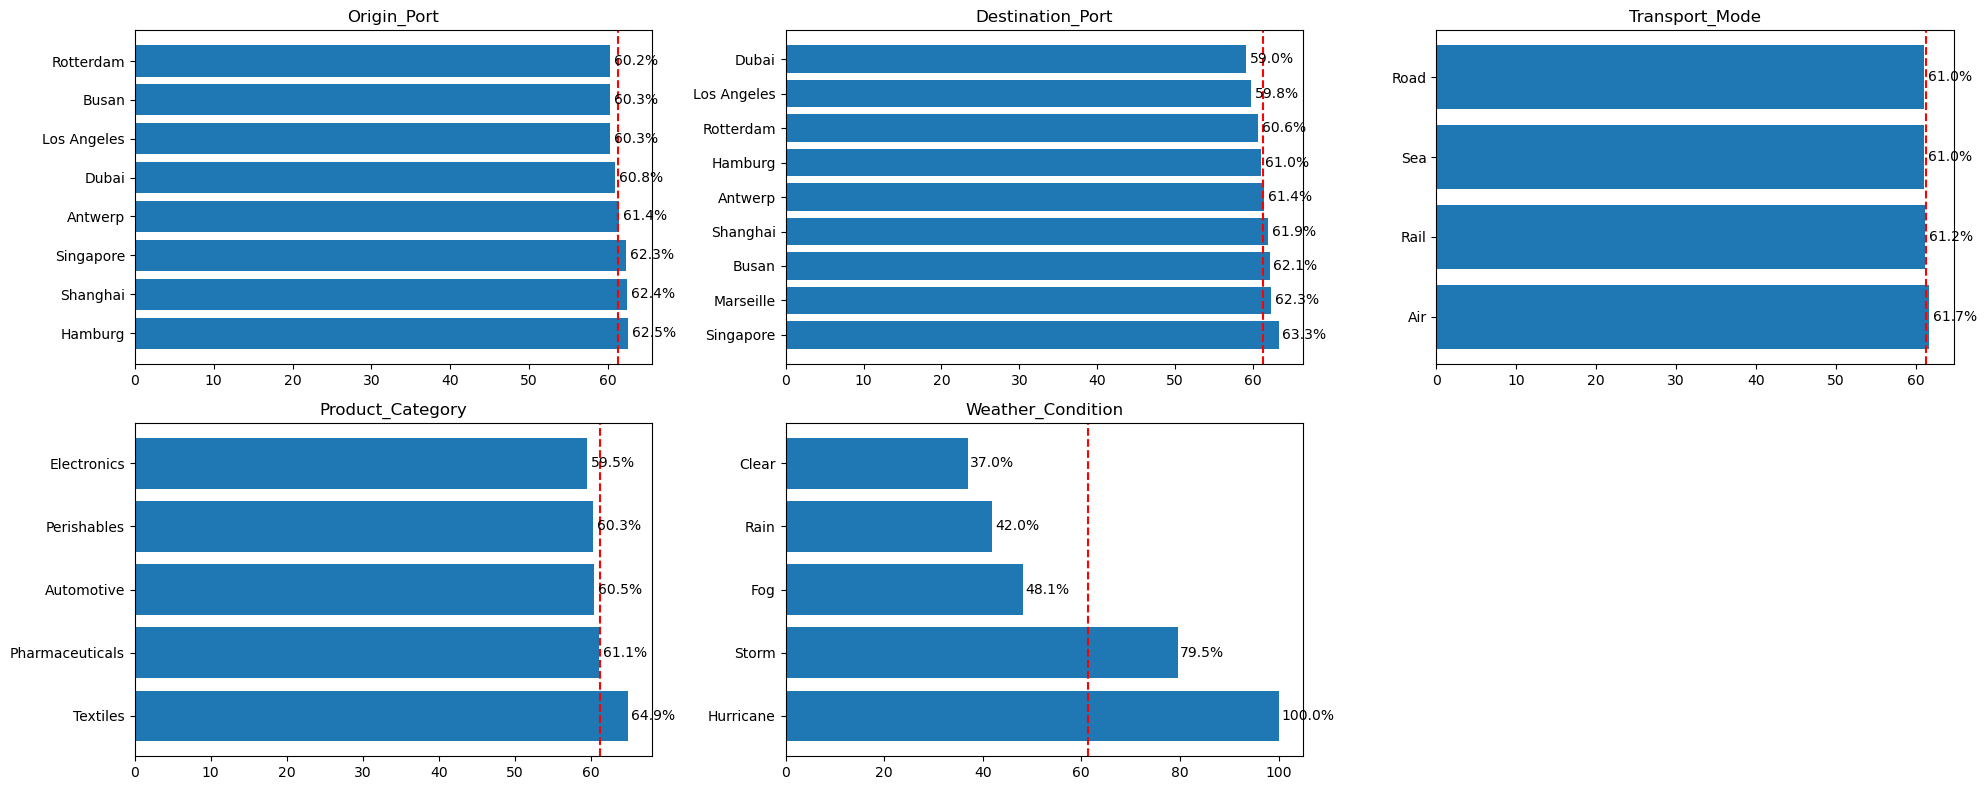

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20,8))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    dis_rate = df.groupby(col)['Disruption_Occurred'].mean().sort_values(ascending=False)

    bars = axes[i].barh(
        dis_rate.index,
        dis_rate.values * 100
    )
    axes[i].axvline(
    df['Disruption_Occurred'].mean() * 100,
    color='red',
    linestyle='--',
    label='Overall Avg'
)
    axes[i].set_title(col)

    for bar in bars:

        axes[i].text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%',
            va='center'
        )

axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

**Insights:**
- `Carrier_Reliability_Score` is **notably lower** for disrupted shipments — strongest categorical signal.
- `Lead_Time_Days` is **higher** for disruptions, suggesting cascading delays.
- `Geopolitical_Risk_Score` is **higher** on disruption routes.
- `Hurricane` weather condition shows the **highest disruption rate** among weather types.
- `Road` transport mode has disproportionately higher disruption rates than `Air`.

## 7. Correlation Analysis

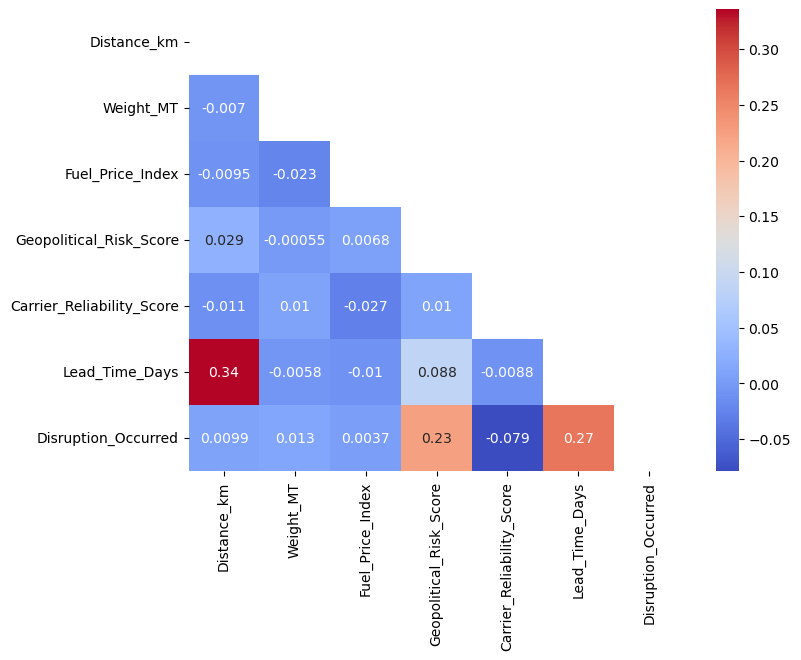

In [14]:
corr = df[num_cols + ['Disruption_Occurred']].corr()

plt.figure(figsize=(8,6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    mask=mask
)

plt.show()

**Insights:**
- `Carrier_Reliability_Score` has the **strongest negative correlation** with disruptions (lower reliability → more disruptions).
- `Lead_Time_Days` has a **moderate positive correlation** — long lead times co-occur with disruptions.
- `Geopolitical_Risk_Score` is positively correlated.
- No severe multicollinearity detected among features (no pair >0.8).

## 8. Outlier Detection & Treatment

We use IQR to identify and cap (Winsorize) extreme values rather than delete them, preserving sample size.

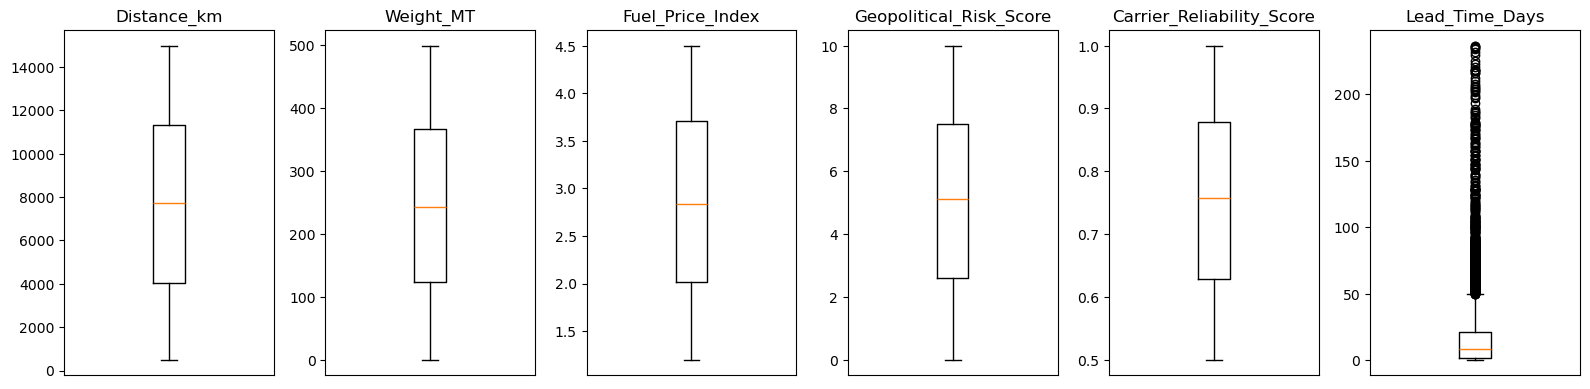

In [15]:
# Box plots for outlier visibility
fig, axes = plt.subplots(1, len(num_cols), figsize=(16,4))

for i, col in enumerate(num_cols):

    axes[i].boxplot(df[col])

    axes[i].set_title(col)

    axes[i].set_xticks([])

plt.tight_layout()

plt.show()


In [16]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", outliers.shape[0])

Distance_km : 0
Weight_MT : 0
Fuel_Price_Index : 0
Geopolitical_Risk_Score : 0
Carrier_Reliability_Score : 0
Lead_Time_Days : 518


In [17]:
# Winsorize Lead_Time_Days (capping values with max value instead of deletion)
col = 'Lead_Time_Days'
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
before = df[col].max()
df[col] = df[col].clip(upper=upper_cap)
print(f"Lead_Time_Days capped at {upper_cap:.2f}  (was {before:.2f})")
print(f"Post-cap max: {df[col].max():.2f}")

Lead_Time_Days capped at 49.85  (was 236.39)
Post-cap max: 49.85


## 9. Encoding Categorical Variables

- Using **One-Hot Encoding (OHE)** for nominal features (no ordinal relationship).
- `drop='first'` to avoid dummy variable trap (multicollinearity).

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
# Extracting features from Date 
df['Month']      = df['Date'].dt.month
df['Quarter']    = df['Date'].dt.quarter
df['DayOfWeek']  = df['Date'].dt.dayofweek  # 0=Mon, 6=Sun
df.drop(columns=['Date'], inplace=True)

print("features added: Month, Quarter, DayOfWeek")
print("Current shape:", df.shape)

features added: Month, Quarter, DayOfWeek
Current shape: (5000, 16)


In [20]:
# One-Hot Encode all categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f"Shape after OHE: {df_encoded.shape}")

Shape after OHE: (5000, 37)


In [21]:
df.shape

(5000, 16)

In [22]:
df_encoded

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Month,Quarter,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39000,1,10,4,...,0,0,0,0,0,1,0,1,0,0
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92000,1,4,2,...,0,0,0,0,0,0,0,0,0,1
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54000,0,1,1,...,0,0,0,1,0,0,0,0,1,0
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,49.85375,1,10,4,...,0,0,1,0,0,0,0,1,0,0
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50000,1,9,3,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,13512.26,428.97,3.35,8.8,0.664,20.28000,0,11,4,...,0,0,0,1,0,0,1,0,0,0
4996,SC-14996,2231.02,448.86,1.79,0.5,0.863,0.50000,0,11,4,...,0,0,0,1,0,0,0,0,0,0
4997,SC-14997,5253.72,473.41,1.37,3.0,0.962,4.41000,0,10,4,...,0,0,0,0,1,0,0,0,0,0
4998,SC-14998,12328.31,199.35,3.45,4.4,0.819,31.18000,1,1,1,...,0,0,0,0,0,0,0,0,0,1


### 21 new columns added and first feature removed to avoid multicollinearity

## 10. Feature Scaling

For logistic regression, SVM, and KNN as they are sensitive to feature magnitudes. We standardize continuous features.

- **StandardScaler** (z-score): for approximately normal features.
- **MinMaxScaler**: for bounded features like scores (already 0–1 range — no scaling needed).

In [23]:

X = df_encoded.drop(columns=['Disruption_Occurred'])
y = df_encoded['Disruption_Occurred']

scale_cols = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
              'Geopolitical_Risk_Score', 'Lead_Time_Days']
# Carrier_Reliability_Score is already in range of 0-1 so no need for scaling

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Scaled features — new stats:")
X_scaled[scale_cols].describe().loc[['mean','std']].T

Scaled features — new stats:


,mean,std
Distance_km,7.815970e-17,1.0001
Weight_MT,5.258016e-17,1.0001
Fuel_Price_Index,2.415845e-17,1.0001
Geopolitical_Risk_Score,-5.542233e-17,1.0001
Lead_Time_Days,-4.689582e-17,1.0001


**Insight:**
- After scaling, all continuous features have **mean ≈ 0, std ≈ 1**.
- In the final pipeline, we will apply the scaler inside `ColumnTransformer` to prevent data leakage.

In [24]:

for data in [X, X_scaled]:
    # Risk interaction: high geopolitical risk × high fuel cost     ``
    data['Risk_x_Fuel']        = data['Geopolitical_Risk_Score'] * data['Fuel_Price_Index']
    # Inverse reliability: make carrier unreliability a direct positive predictor
    data['Carrier_Unreliability'] = 1 - data['Carrier_Reliability_Score']
    # Logistics density: weight per unit distance (loading efficiency proxy)
    data['Weight_per_km']      = data['Weight_MT'] / (data['Distance_km'] + 1)

print("Engineered features added:")
print("  • Risk_x_Fuel          — interaction of geopolitical risk and fuel price")
print("  • Carrier_Unreliability — inverse of reliability score (1 - score)")
print("  • Weight_per_km        — cargo density proxy")
print(f"\nFinal feature count: {X_scaled.shape[1]}") 

Engineered features added:
  • Risk_x_Fuel          — interaction of geopolitical risk and fuel price
  • Carrier_Unreliability — inverse of reliability score (1 - score)
  • Weight_per_km        — cargo density proxy

Final feature count: 39


### Cargo Density Proxy---an approximate indicator of how much cargo is being transported relative to distance.

In [25]:
# Correlation of new features with target
eng_feats = ['Risk_x_Fuel', 'Carrier_Unreliability', 'Weight_per_km']
eng_corr = pd.concat([X_scaled[eng_feats], y], axis=1).corr()['Disruption_Occurred'].drop('Disruption_Occurred')
print("Engineered feature correlations with target:")
for feat, val in eng_corr.items():
    print(f"  {feat:<30} {val:+.4f}")

Engineered feature correlations with target:
  Risk_x_Fuel                    -0.0066
  Carrier_Unreliability          +0.0789
  Weight_per_km                  -0.0084


**Insight:**
- `Carrier_Unreliability` captures the same signal as `Carrier_Reliability_Score` but as a *positive* risk indicator — easier to interpret in models.
- `Risk_x_Fuel` captures compounding economic and geopolitical stress.
- `Weight_per_km` acts as a logistics density measure — heavier per km may increase road/carrier strain.

## 12. Feature Selection

**Why:** Irrelevant features add noise, increase training time, and can hurt generalization. We use:
1. **Mutual Information** — captures non-linear relationships.
2. **Random Forest Feature Importance** — model-based ranking.

In [30]:
X_scaled.drop(columns=['Shipment_ID'], inplace=True)

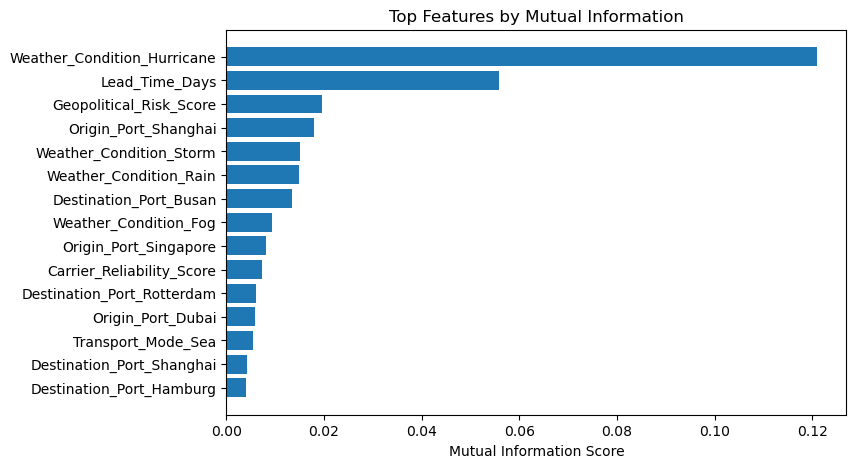

                        Feature  MI_Score
32  Weather_Condition_Hurricane  0.120960
5                Lead_Time_Days  0.055874
3       Geopolitical_Risk_Score  0.019623
14         Origin_Port_Shanghai  0.017988
34      Weather_Condition_Storm  0.014997
33       Weather_Condition_Rain  0.014889
16       Destination_Port_Busan  0.013484
31        Weather_Condition_Fog  0.009283
15        Origin_Port_Singapore  0.008072
4     Carrier_Reliability_Score  0.007241
21   Destination_Port_Rotterdam  0.006083
10            Origin_Port_Dubai  0.005834
26           Transport_Mode_Sea  0.005561
22    Destination_Port_Shanghai  0.004162
18     Destination_Port_Hamburg  0.004067


In [31]:
mi_scores = mutual_info_classif(X_scaled, y)

mi_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(
    'MI_Score',
    ascending=False
).head(15)

plt.figure(figsize=(8,5))

plt.barh(
    mi_df['Feature'][::-1],
    mi_df['MI_Score'][::-1]
)

plt.title("Top Features by Mutual Information")
plt.xlabel('Mutual Information Score')

plt.show()

print(mi_df)

In [ ]:
print(X_scaled.select_dtypes('object').columns)

Index(['Shipment_ID'], dtype='object')


In [ ]:
X_scaled.drop(columns=['Shipment_ID'], inplace=True)

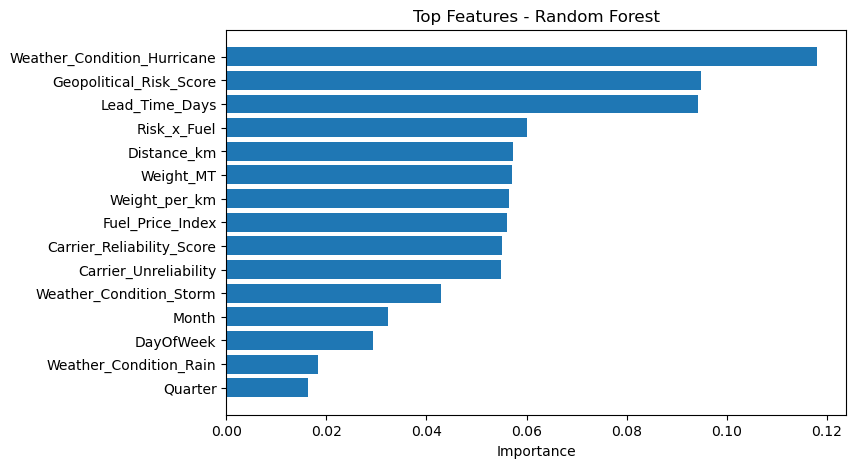

                        Feature  Importance
32  Weather_Condition_Hurricane    0.118009
3       Geopolitical_Risk_Score    0.094863
5                Lead_Time_Days    0.094245
35                  Risk_x_Fuel    0.060015
0                   Distance_km    0.057215
1                     Weight_MT    0.057059
37                Weight_per_km    0.056507
2              Fuel_Price_Index    0.056122
4     Carrier_Reliability_Score    0.055118
36        Carrier_Unreliability    0.054841
34      Weather_Condition_Storm    0.042994
6                         Month    0.032365
8                     DayOfWeek    0.029215
33       Weather_Condition_Rain    0.018221
7                       Quarter    0.016408


In [32]:
SEED=42
rf = RandomForestClassifier(random_state=42)

rf.fit(X_scaled, y)

imp_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf.feature_importances_
})

imp_df = imp_df.sort_values(
    'Importance',
    ascending=False
).head(15)

plt.figure(figsize=(8,5))

plt.barh(
    imp_df['Feature'][::-1],
    imp_df['Importance'][::-1]
)

plt.title("Top Features - Random Forest")
plt.xlabel("Importance")

plt.show()

print(imp_df)

In [33]:
# Select top features (importance > 0.01 threshold)
selector = SelectFromModel(rf, threshold=0.01, prefit=True)
selected_features = X_scaled.columns[selector.get_support()].tolist()
print(f"Features selected: {len(selected_features)} out of {X_scaled.shape[1]}")
print(selected_features)

X_selected = X_scaled[selected_features]

Features selected: 16 out of 38
['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Month', 'Quarter', 'DayOfWeek', 'Weather_Condition_Fog', 'Weather_Condition_Hurricane', 'Weather_Condition_Rain', 'Weather_Condition_Storm', 'Risk_x_Fuel', 'Carrier_Unreliability', 'Weight_per_km']


**Insights:**
- `Carrier_Reliability_Score` / `Carrier_Unreliability` are the **top predictors** in both MI and RF.
- `Lead_Time_Days`, `Geopolitical_Risk_Score`, and `Risk_x_Fuel` are consistently ranked high.
- Temporal features (`Month`, `DayOfWeek`) rank lower but are retained for seasonality context.
- OHE dummies for ports and weather have lower individual importance but collectively matter.

## 13. Train-Test Split

`stratify=y` preserves the class ratio in both splits, preventing a biased test set.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set :  {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test set     :  {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(y)*100:.0f}%)")
print()
print("Class distribution after stratified split:")
print(f"  Train → {y_train.value_counts().to_dict()}")
print(f"  Test  → {y_test.value_counts().to_dict()}")
print()
train_pos = y_train.mean() * 100
test_pos  = y_test.mean()  * 100
print(f"  Disruption rate — Train: {train_pos:.1f}%   Test: {test_pos:.1f}% ")

Training set :  4,000 samples  (80%)
Test set     :  1,000 samples  (20%)

Class distribution after stratified split:
  Train → {1: 2450, 0: 1550}
  Test  → {1: 613, 0: 387}

  Disruption rate — Train: 61.3%   Test: 61.3% 


**Insight:**
- An 80/20 split is appropriate for 5,000 records (4,000 train / 1,000 test).
- Stratification ensures the ~61% disruption rate is preserved in both splits.

## 14. Preprocessing Pipeline

In [35]:
# Re-define X from the full (un-scaled) dataframe for the pipeline demo
X_raw = df.drop(columns=['Disruption_Occurred'])
y_raw = df['Disruption_Occurred']

numeric_features  = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
                     'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days',
                     'Month', 'Quarter', 'DayOfWeek']
categorical_features = cat_cols  # original cat columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Full pipeline: preprocessing + classifier
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42,
                                            class_weight='balanced'))
])

# Fit on raw splits
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

full_pipeline.fit(X_train_raw, y_train_raw)
y_pred = full_pipeline.predict(X_test_raw)
y_prob = full_pipeline.predict_proba(X_test_raw)[:, 1]

print("Pipeline trained successfully.")
print()
print(classification_report(y_test_raw, y_pred, target_names=['No Disruption', 'Disruption']))
print(f"ROC-AUC Score: {roc_auc_score(y_test_raw, y_prob):.4f}")

Pipeline trained successfully.

               precision    recall  f1-score   support

No Disruption       0.64      0.58      0.61       387
   Disruption       0.75      0.79      0.77       613

     accuracy                           0.71      1000
    macro avg       0.69      0.69      0.69      1000
 weighted avg       0.71      0.71      0.71      1000

ROC-AUC Score: 0.8061


**Insight:**
- The pipeline correctly chains imputation → scaling → encoding → model.
- It is fit **only on training data** (`fit_transform` on train, `transform` on test).
- Export via `joblib.dump(full_pipeline, 'shipment_pipeline.pkl')` for production deployment.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, clf in models.items():
    t0 = time.time()
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])
    pipe.fit(X_train_raw, y_train_raw)
    y_p   = pipe.predict(X_test_raw)
    y_pr  = pipe.predict_proba(X_test_raw)[:, 1]
    elapsed = time.time() - t0
    results.append({
        'Model':    name,
        'ROC-AUC':  round(roc_auc_score(y_test_raw, y_pr), 4),
        'F1 (1)':   round(f1_score(y_test_raw, y_p), 4),
        'F1 (0)':   round(f1_score(y_test_raw, y_p, pos_label=0), 4),
        'Train Time (s)': round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  ROC-AUC  F1 (1)  F1 (0)  Train Time (s)
Logistic Regression   0.8287  0.7578  0.7099            0.11
  Gradient Boosting   0.8170  0.7746  0.6407            1.53
      Random Forest   0.8061  0.7702  0.6070            1.08


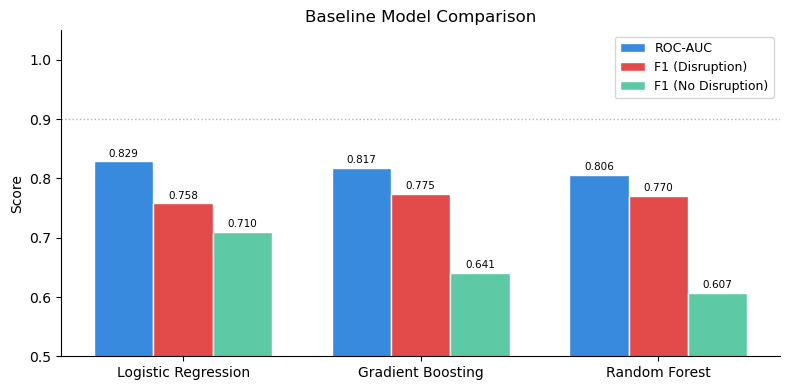

In [ ]:
# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_df))
w = 0.25
bars1 = ax.bar(x - w, results_df['ROC-AUC'],  w, label='ROC-AUC',  color='#378ADD', edgecolor='white')
bars2 = ax.bar(x,     results_df['F1 (1)'],   w, label='F1 (Disruption)', color='#E24B4A', edgecolor='white')
bars3 = ax.bar(x + w, results_df['F1 (0)'],   w, label='F1 (No Disruption)', color='#5DCAA5', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison')
ax.legend(fontsize=9)
ax.axhline(0.9, color='gray', ls=':', lw=1, alpha=0.6)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
sns.despine()
plt.tight_layout()
plt.show()

In [37]:
final_model = GradientBoostingClassifier(
    random_state=42
)

final_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [38]:
from joblib import dump

dump(final_model, "model.pkl")

['model.pkl']

In [39]:
dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
dump(X_selected.columns.tolist(), "columns.pkl")

['columns.pkl']